Question 1: SVM Classifier for Music Genres

c:\Users\Aaryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


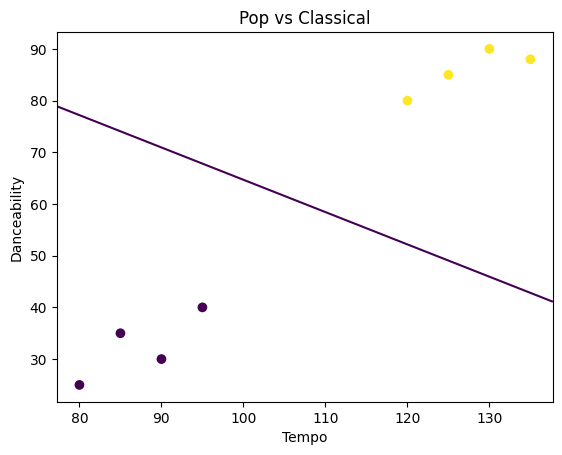

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.svm import SVC

df = pd.DataFrame({
    "tempo":[120,125,130,135,90,85,80,95],
    "danceability":[80,85,90,88,30,35,25,40],
    "genre":[1,1,1,1,0,0,0,0]
})

X = df[["tempo","danceability"]]
y = df["genre"]

model = SVC(kernel="linear")

model.fit(X,y)

plt.scatter(
    df["tempo"],
    df["danceability"],
    c=y
)

ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(
    xlim[0],
    xlim[1],
    100
)

yy = np.linspace(
    ylim[0],
    ylim[1],
    100
)

YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([
    XX.ravel(),
    YY.ravel()
]).T

Z = model.decision_function(xy)

Z = Z.reshape(XX.shape)

plt.contour(
    XX,
    YY,
    Z,
    levels=[0],
)

plt.xlabel("Tempo")
plt.ylabel("Danceability")
plt.title("Pop vs Classical")

plt.show()

Question 2: Flipkart Review Classification

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

reviews = [
    "Excellent product",
    "Very good quality",
    "Worth buying",
    "Amazing phone",
    "Bad product",
    "Waste of money",
    "Poor quality",
    "Not recommended"
]

labels = [
    "positive",
    "positive",
    "positive",
    "positive",
    "negative",
    "negative",
    "negative",
    "negative"
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(reviews)

y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

model = SVC(kernel="linear")

model.fit(X_train,y_train)

predictions = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test,predictions)
)

Accuracy: 0.0


Question 3: Polynomial Kernel vs RBF Kernel

In [3]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

df = pd.DataFrame({
    "runs":[500,600,450,700,300,650,550,400],
    "wickets":[5,2,8,1,10,3,4,9],
    "performance":[1,1,1,1,0,1,1,0]
})

X = df[["runs","wickets"]]

y = df["performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

poly_model = SVC(
    kernel="poly",
    degree=3
)

poly_model.fit(
    X_train,
    y_train
)

poly_pred = poly_model.predict(
    X_test
)

rbf_model = SVC(
    kernel="rbf"
)

rbf_model.fit(
    X_train,
    y_train
)

rbf_pred = rbf_model.predict(
    X_test
)

print(
    "Polynomial Accuracy:",
    accuracy_score(y_test, poly_pred)
)

print(
    "RBF Accuracy:",
    accuracy_score(y_test, rbf_pred)
)

Polynomial Accuracy: 1.0
RBF Accuracy: 1.0


Question 4: Visualizing Margin and Support Vectors

c:\Users\Aaryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


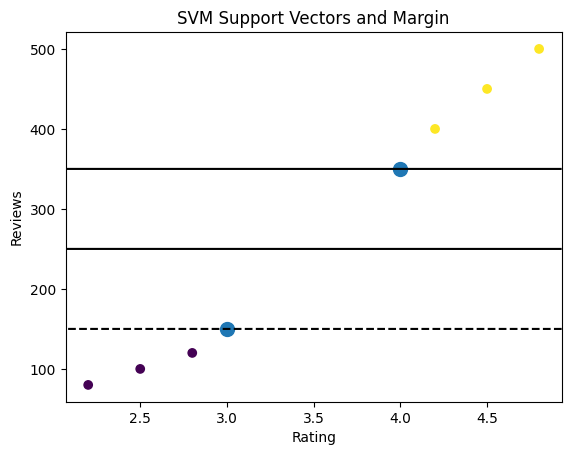

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.svm import SVC

df = pd.DataFrame({
    "rating":[4.8,4.5,4.2,4.0,2.5,2.8,3.0,2.2],
    "reviews":[500,450,400,350,100,120,150,80],
    "class":[1,1,1,1,0,0,0,0]
})

X = df[["rating","reviews"]]

y = df["class"]

model = SVC(
    kernel="linear"
)

model.fit(X,y)

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y
)

ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(
    xlim[0],
    xlim[1],
    100
)

yy = np.linspace(
    ylim[0],
    ylim[1],
    100
)

YY, XX = np.meshgrid(
    yy,
    xx
)

xy = np.vstack([
    XX.ravel(),
    YY.ravel()
]).T

Z = model.decision_function(xy)

Z = Z.reshape(
    XX.shape
)

plt.contour(
    XX,
    YY,
    Z,
    colors="k",
    levels=[-1,0,1]
)

plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=100
)

plt.xlabel("Rating")
plt.ylabel("Reviews")

plt.title(
    "SVM Support Vectors and Margin"
)

plt.show()